Cluster sizes (customers):
 segment
0    1139
1     120
2     567
3     174
Name: count, dtype: int64

Cluster centroids (in standardized units):
    transaction_amount_kzt_sum  transaction_amount_kzt_mean  \
0                   -0.617270                     0.025693   
1                    1.293042                    -0.230798   
2                    0.559068                     0.202638   
3                    1.327094                    -0.669331   

   transaction_amount_kzt_std  merchant_city_code_sum  \
0                   -0.084258               -0.627305   
1                   -0.057217                1.272746   
2                    0.272793                0.272870   
3                   -0.297916                2.339393   

   merchant_city_code_mean  merchant_city_code_std  transaction_type_1_sum  \
0                -0.030640               -0.086110               -0.449741   
1                 0.038645               -0.143217               -0.036287   
2                 0.04

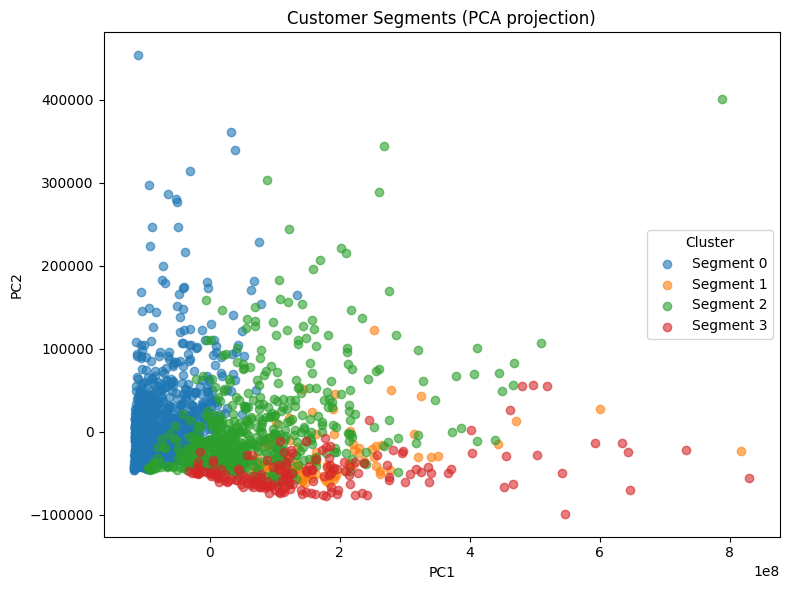

In [1]:
import pandas as pd
from customer_segmentation_per_user import aggregate_features, cluster_and_assign, plot_segments

# 1. Load & aggregate (one row per customer)
df = pd.read_csv('/Users/lithrur/Desktop/Coding projects/hackathon_2025_ai/dataset/dataset_cleaned.csv')
cust_feats = aggregate_features(df)      # DataFrame indexed by card_id

# 2. Cluster and get back the fitted pipeline
cust_segmented, pipeline = cluster_and_assign(cust_feats, n_clusters=4)

# 3. Exact number of people in each segment
counts = cust_segmented['segment'].value_counts().sort_index()
print("Cluster sizes (customers):\n", counts)

# 4. Extract cluster centers in the **scaled** space, then un-scale them if you want
centers = pipeline.named_steps['clusterer'].cluster_centers_
feat_names = cust_feats.columns
center_df = pd.DataFrame(centers, columns=feat_names, index=range(4))
print("\nCluster centroids (in standardized units):\n", center_df)

# 5. Which features vary most across clusters?
#    Compute the total spread (max−min) for each feature over the 4 centers:
feature_importance = (center_df.max() - center_df.min()).sort_values(ascending=False)
print("\nTop 10 features by between‐cluster variance:\n", feature_importance.head(10))

# 6. Finally: visualize so you can see the 4 segments in 2D
plot_segments(cust_segmented)

In [3]:
for i in range(4):
    print(f"Cluster {i} top features:\n",
          center_df.loc[i].sort_values(ascending=False).head(5), "\n")

Cluster 0 top features:
 transaction_amount_kzt_mean    0.025693
merchant_city_code_mean       -0.030640
transaction_amount_kzt_std    -0.084258
merchant_city_code_std        -0.086110
transaction_type_2_sum        -0.372636
Name: 0, dtype: float64 

Cluster 1 top features:
 transaction_type_3_sum    3.224476
pos_entry_mode_3.0_sum    3.224476
transaction_type_6_sum    3.076370
transaction_type_5_sum    2.926198
wallet_type_3_sum         2.241772
Name: 1, dtype: float64 

Cluster 2 top features:
 transaction_type_2_sum                  0.717073
wallet_type_5_sum                       0.680185
transaction_type_7_sum                  0.618212
pos_entry_mode_2.886929362258171_sum    0.617476
transaction_amount_kzt_sum              0.559068
Name: 2, dtype: float64 

Cluster 3 top features:
 transaction_type_1_sum    2.867970
pos_entry_mode_5.0_sum    2.867812
pos_entry_mode_4.0_sum    2.824549
wallet_type_2_sum         2.824549
pos_entry_mode_2.0_sum    2.733264
Name: 3, dtype: float64 

